# 🌱 Exploratory Data Analysis (EDA)

This notebook performs the **Exploratory Data Analysis (EDA)** after the dataset has already been cleaned.

### EDA goals
1. Understand the statistical properties and distributions of the numerical variables.
2. Explore the distribution of categorical variables.
3. Investigate how `result` changes across crops, soil types, and growth stages.
4. Visualize relationships between environmental variables such as moisture, temperature, and humidity.
5. Identify correlations and potential patterns that can be useful for the next modeling stage.

> **Important:** The variable `result` is treated as the target/outcome variable. The analysis describes associations in the data; it does **not** establish causation.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("cleaned_data.csv")

# Display basic information
print(f"Dataset shape: {df.shape}")
display(df.head())
display(df.info())


Dataset shape: (15161, 10)


,crop_name,soil_type,seedling_stage,moi,temp,humidity,result,growth_stage_order,moi_temp_ratio,moi_humidity_index
0,Wheat,Black Soil,Germination,1,25,80.0,1,1,0.0400,0.80
1,Wheat,Black Soil,Germination,2,26,77.0,1,1,0.0769,1.54
2,Wheat,Black Soil,Germination,3,27,74.0,1,1,0.1111,2.22
3,Wheat,Black Soil,Germination,4,28,71.0,1,1,0.1429,2.84
4,Wheat,Black Soil,Germination,5,29,68.0,1,1,0.1724,3.40


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15161 entries, 0 to 15160
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   crop_name           15161 non-null  object 
 1   soil_type           15161 non-null  object 
 2   seedling_stage      15161 non-null  object 
 3   moi                 15161 non-null  int64  
 4   temp                15161 non-null  int64  
 5   humidity            15161 non-null  float64
 6   result              15161 non-null  int64  
 7   growth_stage_order  15161 non-null  int64  
 8   moi_temp_ratio      15161 non-null  float64
 9   moi_humidity_index  15161 non-null  float64
dtypes: float64(3), int64(4), object(3)
memory usage: 1.2+ MB


None

## 1. Dataset Overview

### Why did we do this?
Before creating visualizations, we need to confirm the dataset dimensions, variable types, and the overall structure of the cleaned data.

### What should we look for?
- Number of observations and features.
- Numerical vs. categorical variables.
- Whether the variables have the expected data types.
- Whether there are obvious structural issues that could affect EDA.


In [2]:
# Summary of variable types and unique values
overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "unique_values": df.nunique(),
    "missing_values": df.isna().sum()
})
display(overview)


,dtype,unique_values,missing_values
crop_name,object,5,0
soil_type,object,7,0
seedling_stage,object,8,0
moi,int64,100,0
temp,int64,34,0
humidity,float64,106,0
result,int64,2,0
growth_stage_order,int64,8,0
moi_temp_ratio,float64,1080,0
moi_humidity_index,float64,1805,0


## 2. Descriptive Statistics

### Why did we do this?
Descriptive statistics give us a compact numerical picture of the dataset. For continuous variables, we examine the **mean, median, standard deviation, minimum, maximum, and quartiles**.

The median is particularly useful because it is less sensitive to extreme values than the mean, while the standard deviation shows how widely observations vary around the mean.

### Interpretation
The output below allows us to compare the typical values and variability of:
- `moi` — moisture-related measurement
- `temp` — temperature
- `humidity` — humidity
- `moi_temp_ratio` — engineered moisture/temperature relationship
- `moi_humidity_index` — engineered moisture/humidity relationship

The target `result` is binary, so its mean can also be interpreted as the proportion of observations where `result = 1`.


In [3]:
numeric_cols = df.select_dtypes(include=np.number).columns

desc = df[numeric_cols].describe().T
desc["median"] = df[numeric_cols].median()
desc["variance"] = df[numeric_cols].var()
desc = desc[["count", "mean", "median", "std", "min", "25%", "50%", "75%", "max", "variance"]]

display(desc.round(3))


,count,mean,median,std,min,25%,50%,75%,max,variance
moi,15161.0,42.017,39.000,27.134,1.000,19.000,39.000,61.0,100.0,736.274
temp,15161.0,28.432,28.000,9.729,13.000,20.000,28.000,37.0,46.0,94.659
humidity,15161.0,64.348,71.000,22.582,15.000,45.000,71.000,84.0,91.0,509.930
result,15161.0,0.411,0.000,0.492,0.000,0.000,0.000,1.0,1.0,0.242
growth_stage_order,15161.0,3.526,3.000,1.962,1.000,2.000,3.000,5.0,8.0,3.849
moi_temp_ratio,15161.0,1.582,1.465,1.048,0.022,0.737,1.465,2.3,6.0,1.099
moi_humidity_index,15161.0,25.600,22.620,17.590,0.200,10.620,22.620,38.0,79.2,309.422


## 3. Distribution of Numerical Variables — Histograms

### Why did we do this visualization?
Histograms show the **shape of each numerical distribution**. They help us detect:
- skewness,
- concentration of observations,
- possible multiple modes,
- unusual/extreme values,
- and whether the variable covers a narrow or wide range.

### What can we conclude?
The distributions should be interpreted individually. In particular, we want to see whether environmental measurements such as moisture, temperature, and humidity are evenly distributed or concentrated in specific ranges.

The engineered ratio/index variables are also inspected because their distributions may be different from their original variables.


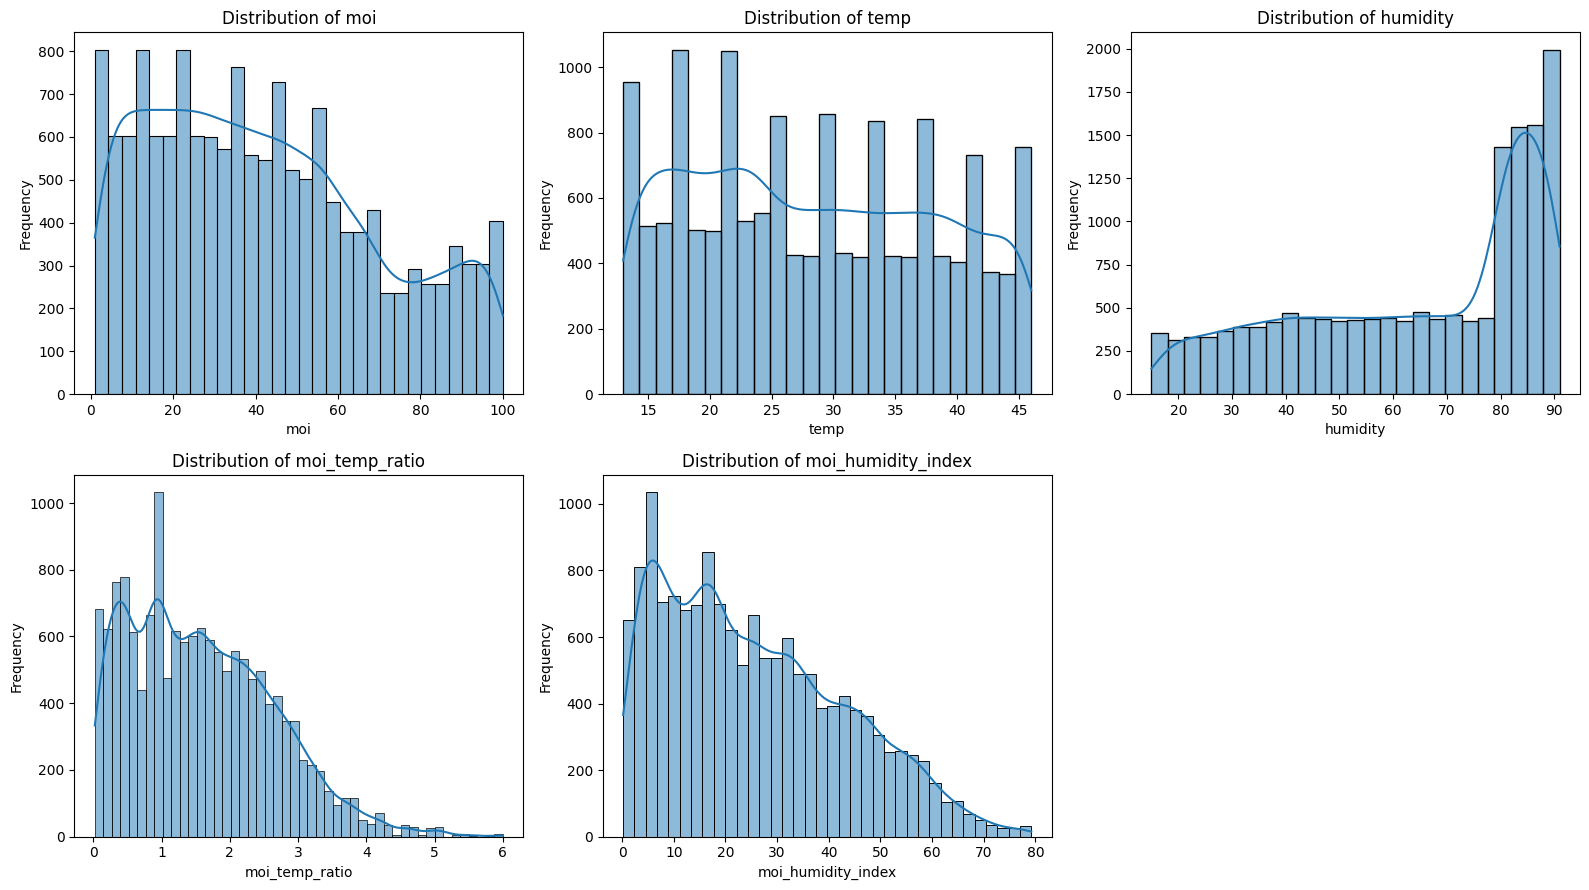

In [4]:
num_cols = ["moi", "temp", "humidity", "moi_temp_ratio", "moi_humidity_index"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

# Hide unused axis
for j in range(len(num_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


## 4. Numerical Variables — Boxplots

### Why did we do this visualization?
Boxplots provide a compact view of the **median, interquartile range, and potential extreme observations**.

They complement the histograms:
- Histogram → shape of the distribution.
- Boxplot → spread and potential outliers.

### Interpretation
A wider box indicates greater variability in the middle 50% of observations. Points beyond the whiskers may represent extreme observations. Because the dataset has already been cleaned, these observations should not automatically be removed; they may represent legitimate agricultural conditions.


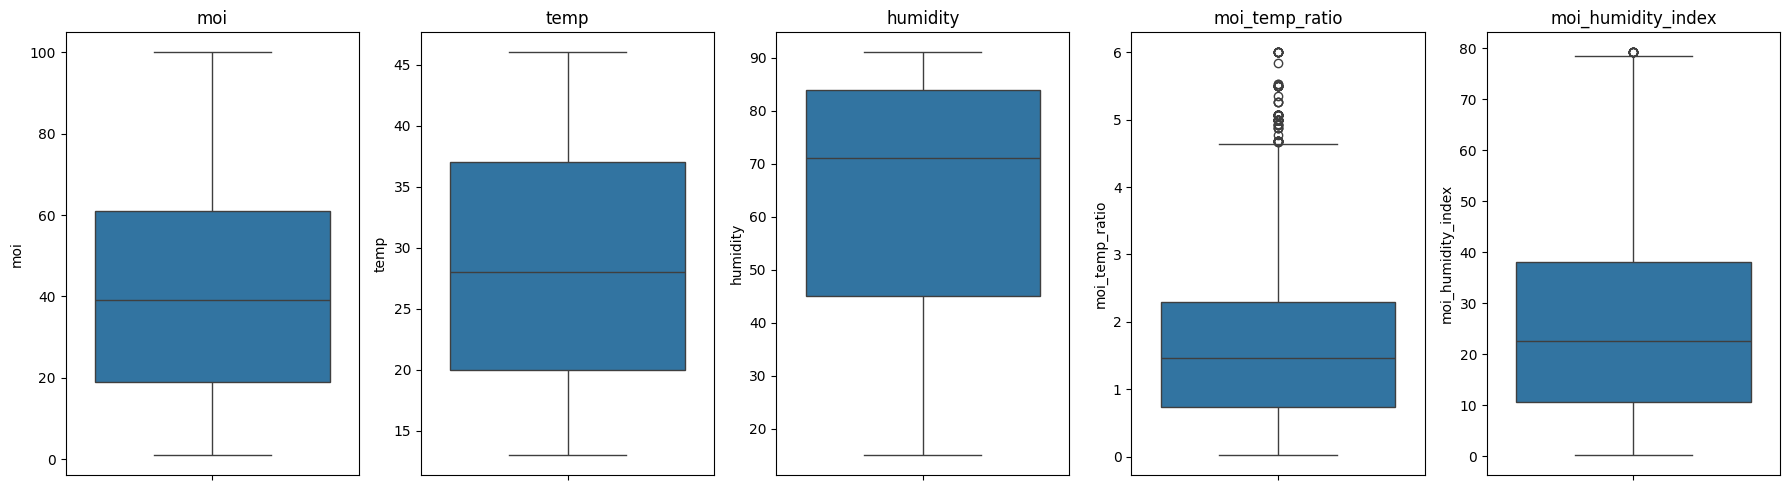

In [5]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 5))

for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()


## 5. Distribution of Categorical Variables

### Why did we do this visualization?
The categorical variables describe the agricultural context:
- crop,
- soil type,
- seedling/growth stage.

A count plot helps us determine whether the dataset is balanced across categories or dominated by a few groups.

### Why does this matter?
If one category has far more observations than another, a simple comparison of raw counts can be misleading. Later, when comparing `result`, we should use **rates/proportions** in addition to counts.


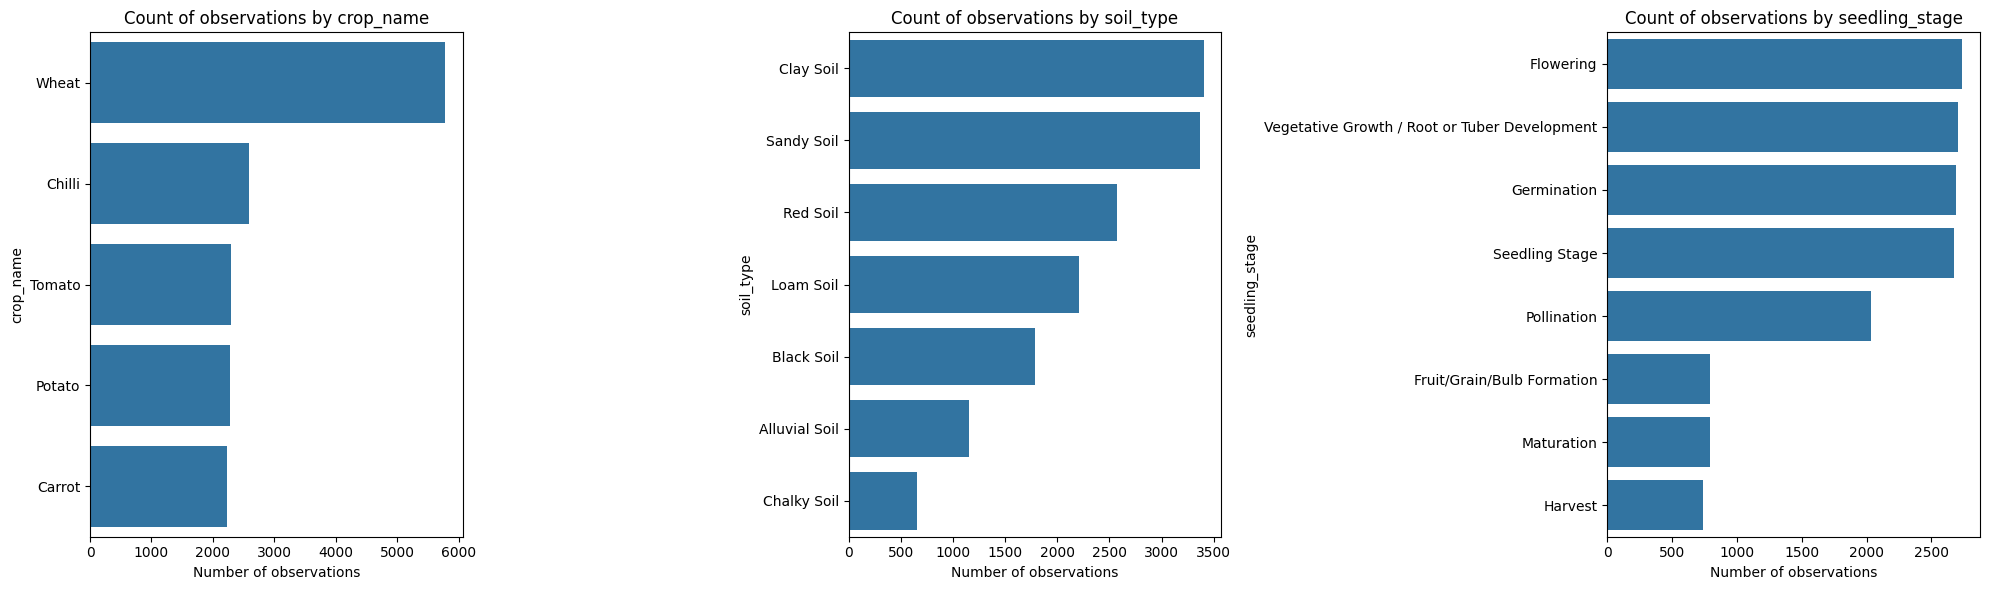

In [6]:
cat_cols = ["crop_name", "soil_type", "seedling_stage"]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, col in zip(axes, cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax)
    ax.set_title(f"Count of observations by {col}")
    ax.set_xlabel("Number of observations")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()


## 6. Target Variable Distribution

### Why did we do this visualization?
Before analyzing relationships with the target, we need to know how the two outcome classes are distributed.

This is important because a highly imbalanced target can make accuracy a misleading evaluation metric during modeling.

### Interpretation
The bar chart shows the number of observations for `result = 0` and `result = 1`. We also report the percentage of each class.


,count,percentage
result,,
0,8934,58.93
1,6227,41.07


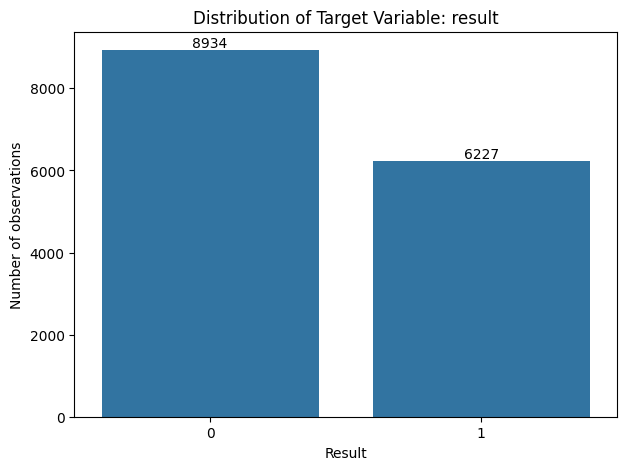

In [7]:
result_counts = df["result"].value_counts().sort_index()
result_pct = df["result"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "count": result_counts,
    "percentage": result_pct.round(2)
})
display(target_summary)

plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x="result", order=sorted(df["result"].unique()))

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Target Variable: result")
plt.xlabel("Result")
plt.ylabel("Number of observations")
plt.show()


## 7. `result` Rate by Crop

### Why did we do this visualization?
The crop type may be associated with different environmental requirements. Therefore, we compare the **proportion of `result = 1`** for each crop rather than comparing raw numbers.

### What does the visualization tell us?
A higher bar means that `result = 1` occurs more frequently within that crop in this dataset.

This identifies differences between crops that may be useful features for predictive modeling. However, these are observational associations and should not be interpreted as proof that crop type causes the outcome.


,mean,count,result_rate_percent
crop_name,,,
Chilli,0.452224,2585,45.22
Carrot,0.432735,2230,43.27
Tomato,0.417031,2290,41.70
Potato,0.405702,2280,40.57
Wheat,0.383137,5776,38.31


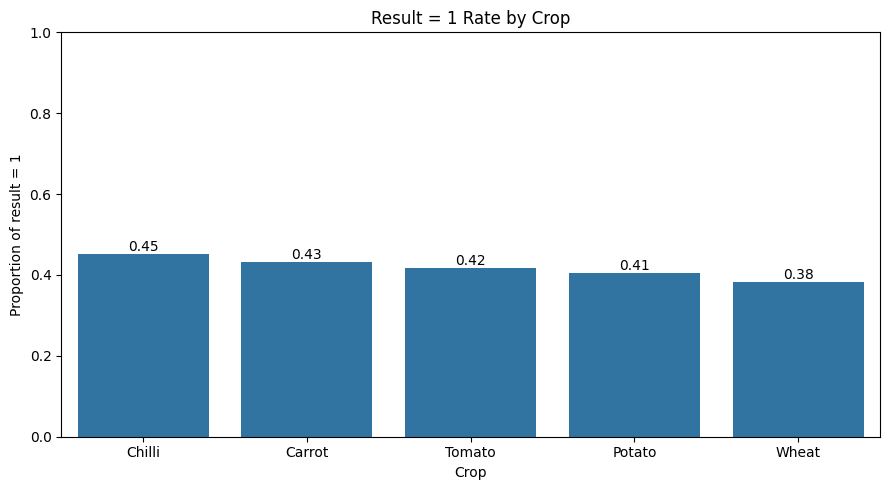

In [8]:
crop_result = (
    df.groupby("crop_name")["result"]
      .agg(["mean", "count"])
      .sort_values("mean", ascending=False)
)

display(crop_result.assign(result_rate_percent=(crop_result["mean"] * 100).round(2)))

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    x=crop_result.index,
    y=crop_result["mean"]
)
ax.set_title("Result = 1 Rate by Crop")
ax.set_xlabel("Crop")
ax.set_ylabel("Proportion of result = 1")
ax.set_ylim(0, 1)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.show()


## 8. `result` Rate by Soil Type

### Why did we do this visualization?
Soil type is an important agricultural context variable. Instead of plotting the number of records per soil type, we calculate the **within-soil result rate**.

### Interpretation
The chart highlights which soil categories have relatively higher or lower proportions of `result = 1`.

Differences between soil types may indicate that soil conditions interact with the environmental measurements or crop requirements. This relationship should be investigated further with grouped analysis and, eventually, a predictive model.


,mean,count,result_rate_percent
soil_type,,,
Chalky Soil,0.455657,654,45.57
Loam Soil,0.418363,2211,41.84
Sandy Soil,0.415727,3370,41.57
Red Soil,0.412883,2577,41.29
Black Soil,0.407263,1790,40.73
Clay Soil,0.401704,3403,40.17
Alluvial Soil,0.383218,1156,38.32


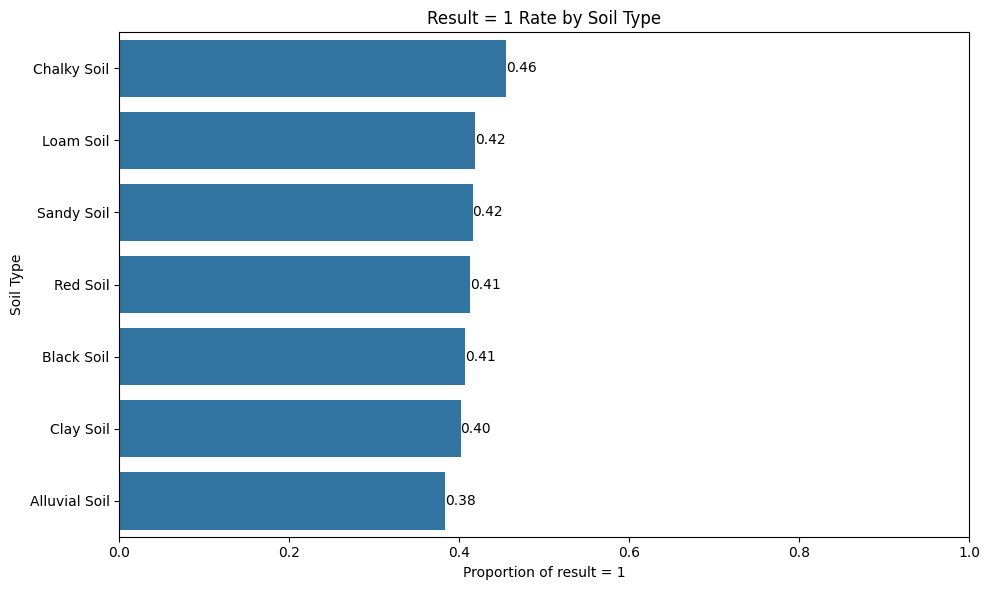

In [9]:
soil_result = (
    df.groupby("soil_type")["result"]
      .agg(["mean", "count"])
      .sort_values("mean", ascending=False)
)

display(soil_result.assign(result_rate_percent=(soil_result["mean"] * 100).round(2)))

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    y=soil_result.index,
    x=soil_result["mean"]
)
ax.set_title("Result = 1 Rate by Soil Type")
ax.set_xlabel("Proportion of result = 1")
ax.set_ylabel("Soil Type")
ax.set_xlim(0, 1)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.show()


## 9. `result` Rate Across Growth Stages

### Why did we do this visualization?
Agricultural conditions can change considerably throughout the plant lifecycle. We therefore compare the target rate across the ordered growth stages.

### Interpretation
The bars allow us to see whether `result = 1` is relatively more common at particular stages.

Because `growth_stage_order` represents an ordered process, the stage order is preserved rather than alphabetically sorted.


,growth_stage_order,seedling_stage,mean,count,result_rate_percent
0,1,Germination,0.406912,2691,40.69
1,2,Seedling Stage,0.400898,2674,40.09
2,3,Vegetative Growth / Root or Tuber Development,0.407832,2707,40.78
3,4,Flowering,0.429145,2738,42.91
4,5,Pollination,0.391925,2031,39.19
5,6,Fruit/Grain/Bulb Formation,0.436709,790,43.67
6,7,Maturation,0.436709,790,43.67
7,8,Harvest,0.398649,740,39.86


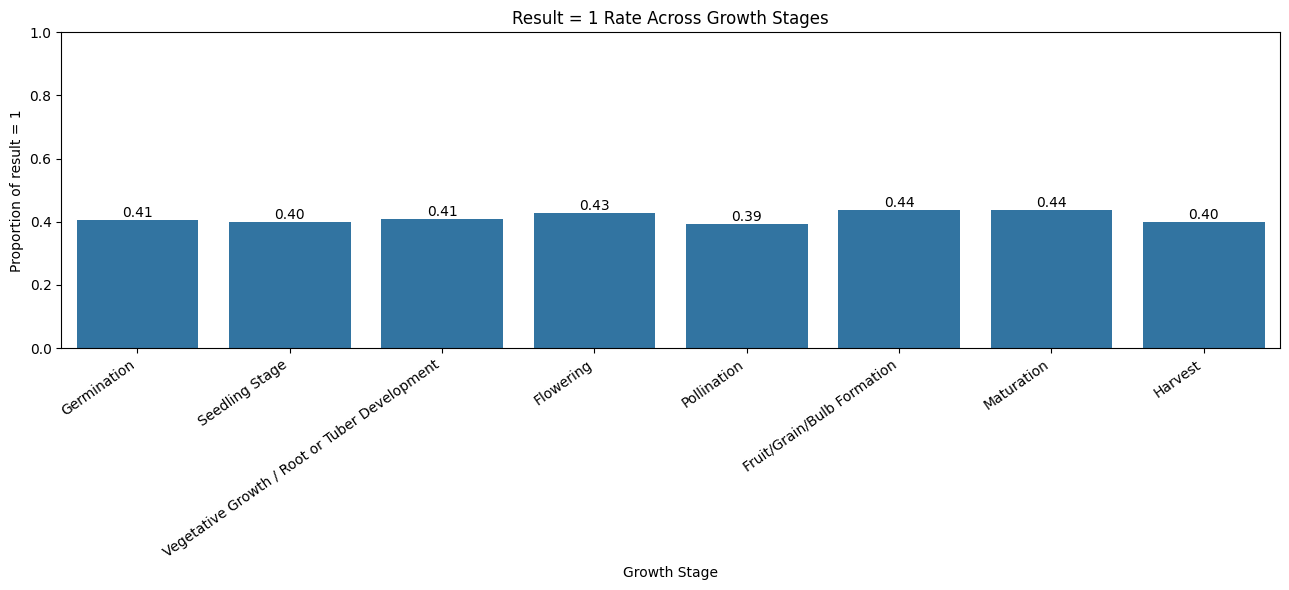

In [10]:
stage_order = (
    df[["growth_stage_order", "seedling_stage"]]
    .drop_duplicates()
    .sort_values("growth_stage_order")
)

stage_result = (
    df.groupby(["growth_stage_order", "seedling_stage"])["result"]
      .agg(["mean", "count"])
      .reset_index()
      .sort_values("growth_stage_order")
)

display(stage_result.assign(result_rate_percent=(stage_result["mean"] * 100).round(2)))

plt.figure(figsize=(13, 6))
ax = sns.barplot(
    data=stage_result,
    x="seedling_stage",
    y="mean",
    order=stage_result["seedling_stage"],
)
ax.set_title("Result = 1 Rate Across Growth Stages")
ax.set_xlabel("Growth Stage")
ax.set_ylabel("Proportion of result = 1")
ax.set_ylim(0, 1)
plt.xticks(rotation=35, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.show()


## 10. Environmental Variables by `result` — Boxplots

### Why did we do this visualization?
We now compare the distributions of the main environmental variables between the two target classes.

This helps answer questions such as:
- Do observations with `result = 1` tend to have different moisture levels?
- Is temperature distributed differently between the two outcomes?
- Does humidity show a visible separation?

### Interpretation
If the boxes/medians are clearly separated, the corresponding variable may contain predictive information about `result`.

A visible difference is an EDA finding, not evidence of causality.


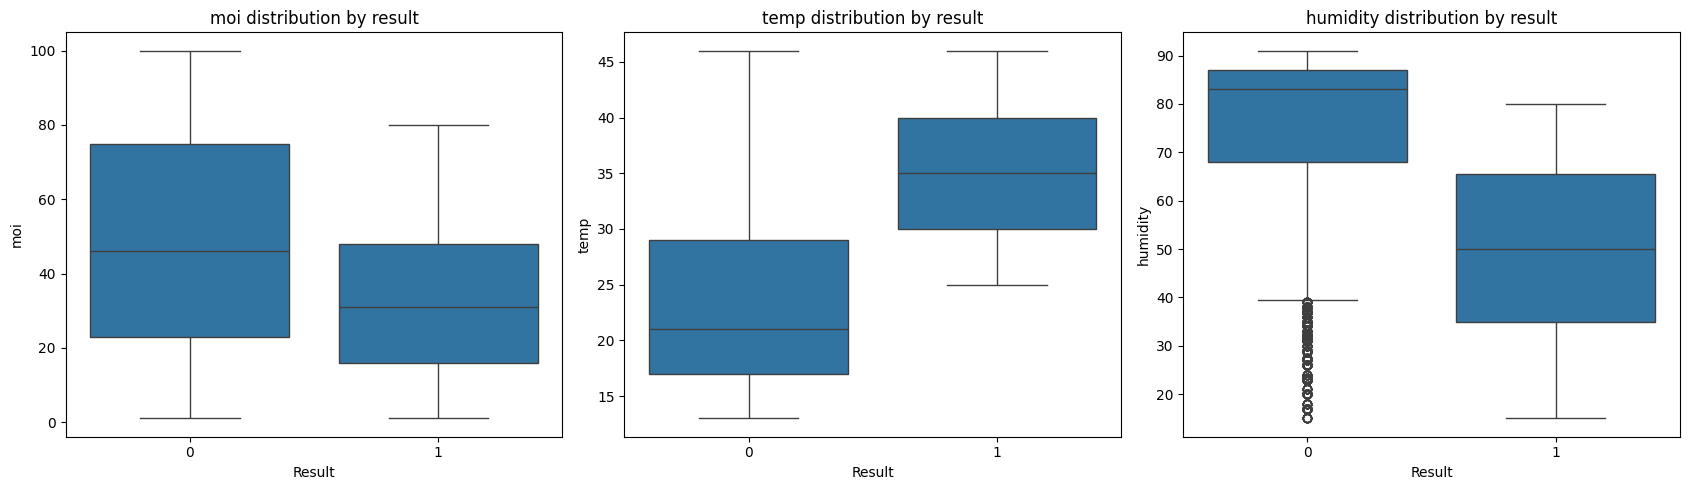

In [11]:
env_cols = ["moi", "temp", "humidity"]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, col in zip(axes, env_cols):
    sns.boxplot(data=df, x="result", y=col, ax=ax)
    ax.set_title(f"{col} distribution by result")
    ax.set_xlabel("Result")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()


## 11. Temperature vs. Humidity — Relationship with the Target

### Why did we do this visualization?
Temperature and humidity may be strongly related in the collected data. A scatter plot helps us inspect their joint relationship and see whether the two `result` classes occupy different regions.

### Interpretation
We are looking for:
- the overall relationship between temperature and humidity,
- clustering/separation of the target classes,
- and areas where the two classes overlap.

Strong overlap means that neither variable alone perfectly separates the target.


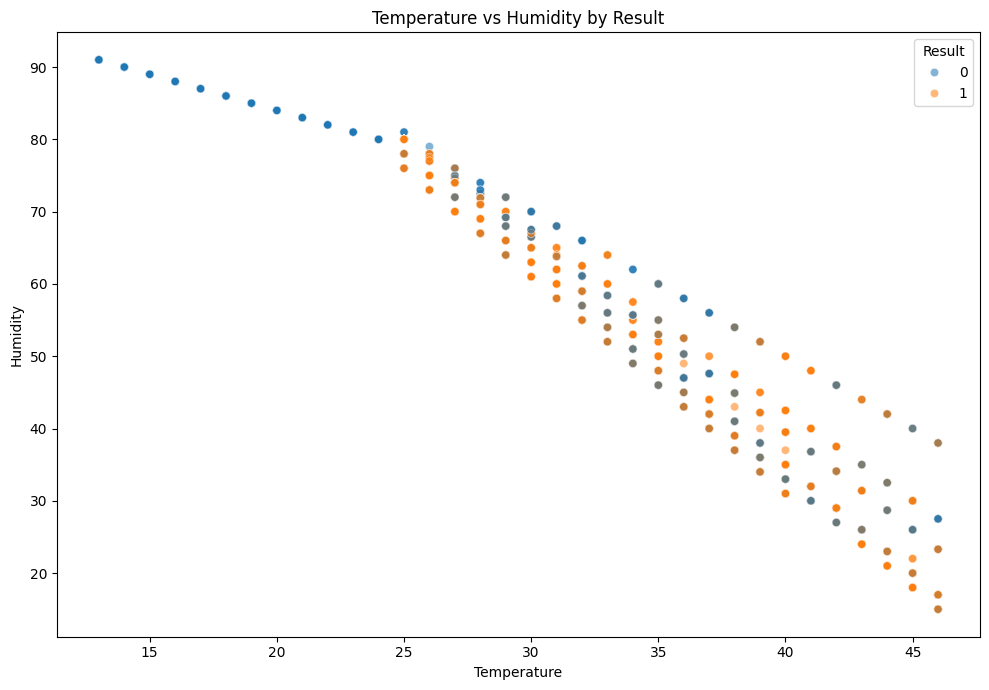

In [12]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df.sample(min(5000, len(df)), random_state=42),
    x="temp",
    y="humidity",
    hue="result",
    alpha=0.55
)
plt.title("Temperature vs Humidity by Result")
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.legend(title="Result")
plt.tight_layout()
plt.show()


## 12. Correlation Matrix

### Why did we do this visualization?
A correlation heatmap summarizes the **linear relationships** among numerical variables.

This is useful for:
- identifying variables that move together,
- detecting potentially redundant engineered features,
- and understanding which numerical variables have stronger linear association with `result`.

### Important caution
Correlation does **not** imply causation, and Pearson correlation mainly captures linear association.

The engineered variables (`moi_temp_ratio` and `moi_humidity_index`) are mathematically related to the original variables, so strong correlations involving them are expected and should be considered when building a model.


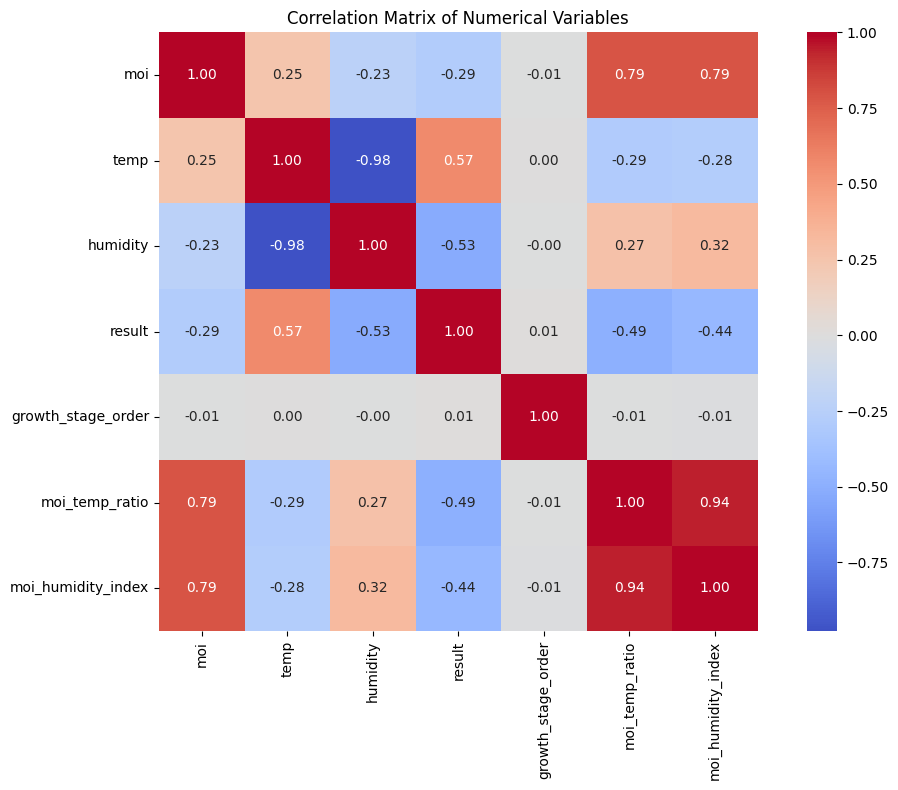

,correlation_with_result
temp,0.570059
humidity,-0.527757
moi_temp_ratio,-0.494089
moi_humidity_index,-0.442184
moi,-0.286134
growth_stage_order,0.008192


In [13]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

result_corr = corr["result"].drop("result").sort_values(key=lambda s: s.abs(), ascending=False)
display(result_corr.to_frame("correlation_with_result"))


## 13. Correlation-Focused Visualization

### Why did we do this visualization?
The full heatmap contains many relationships. This focused bar chart makes it easier to compare the numerical variables specifically by their correlation with `result`.

### Interpretation
- Positive correlation → higher values tend to be associated with higher values of `result`.
- Negative correlation → higher values tend to be associated with lower values of `result`.
- Values close to zero → weak linear association.

These values should be treated as **screening-level evidence**, not as a final feature-selection rule.


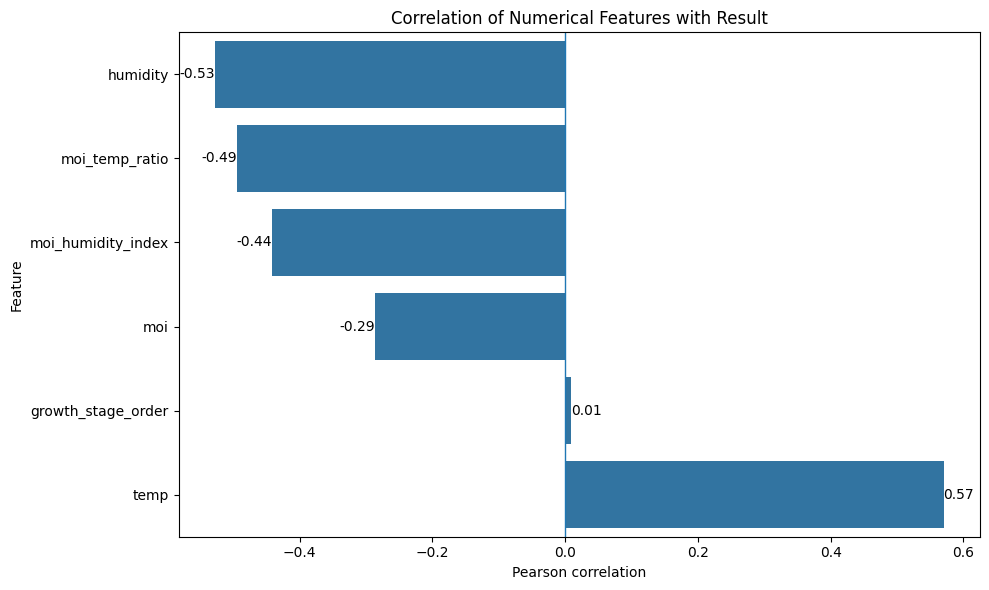

In [14]:
result_corr = (
    df.select_dtypes(include=np.number)
      .corr()["result"]
      .drop("result")
      .sort_values()
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=result_corr.values,
    y=result_corr.index
)
ax.set_title("Correlation of Numerical Features with Result")
ax.set_xlabel("Pearson correlation")
ax.set_ylabel("Feature")
ax.axvline(0, linewidth=1)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.show()


## 14. Multivariate View — Result by Crop and Soil Type

### Why did we do this visualization?
A variable may look important by itself but behave differently across groups. A heatmap of `result` rate by **crop × soil type** lets us inspect an interaction between two categorical variables.

### Interpretation
Each cell represents the proportion of `result = 1` for a specific crop/soil combination.

Large differences between cells suggest that the outcome may depend on combinations of agricultural conditions rather than on one categorical variable alone.


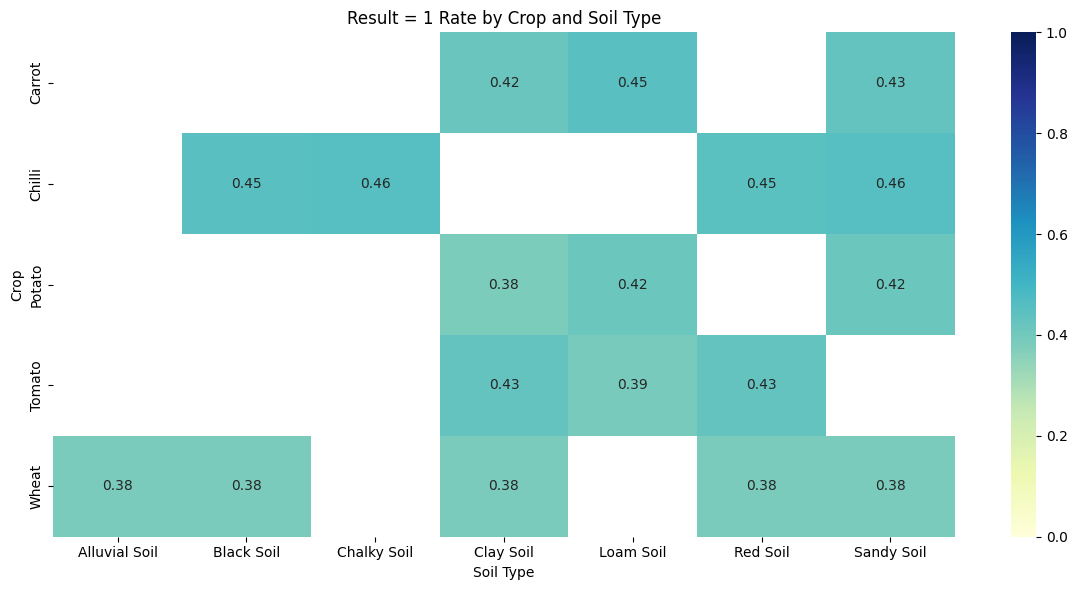

In [15]:
crop_soil = pd.pivot_table(
    df,
    values="result",
    index="crop_name",
    columns="soil_type",
    aggfunc="mean"
)

plt.figure(figsize=(12, 6))
sns.heatmap(
    crop_soil,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1
)
plt.title("Result = 1 Rate by Crop and Soil Type")
plt.xlabel("Soil Type")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()


# 15. Key EDA Findings

Based on the visualizations and descriptive analysis, the main findings are:

### 📊 Distribution
- The dataset contains **15,161 observations and 10 variables**.
- The target `result` contains two classes, so target balance should be considered before model evaluation.
- Numerical variables show different ranges and levels of dispersion, which supports examining distributions before modeling.

### 🌱 Agricultural categories
- The distribution of observations is not identical across crops, soil types, and growth stages.
- The `result = 1` rate varies across **crop type**, **soil type**, and **growth stage**, indicating that these categorical variables may contain useful predictive information.

### 🌡️ Environmental relationships
- Temperature and humidity show a strong inverse linear relationship in this dataset.
- Moisture is positively related to the engineered moisture-based features.
- The environmental variables show visible differences between the two `result` classes, suggesting potential predictive value.

### 🔗 Correlations
- The strongest numerical associations with `result` should be considered during feature analysis.
- The engineered features are highly correlated with each other and with `moi`, which indicates potential **multicollinearity/redundancy**.

### ⚠️ Modeling implication
EDA suggests that the problem is not purely one-dimensional: the outcome appears to vary across environmental conditions and agricultural categories. Therefore, the next stage should investigate feature importance, interactions, and appropriate model performance metrics rather than relying on a single variable or accuracy alone.

> **Note:** These findings describe associations present in the dataset. They should not be interpreted as causal agricultural conclusions without experimental or domain-specific evidence.
